# **Tech Stock Market Analysis & Trend Detection - Project**

## **Import Important Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Read CSV File in Pandas**

In [2]:
df = pd.read_csv("C:/Users/Sushil Kumar/OneDrive/Desktop/New folder/StockTrend Analytics/major-tech-stock-2019-2024.csv")

In [3]:
df

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL
...,...,...,...,...,...,...,...,...
6285,2023-12-22,256.760010,258.220001,251.369995,252.539993,252.539993,93249800,TSLA
6286,2023-12-26,254.490005,257.970001,252.910004,256.609985,256.609985,86892400,TSLA
6287,2023-12-27,258.350006,263.339996,257.519989,261.440002,261.440002,106494400,TSLA
6288,2023-12-28,263.660004,265.130005,252.710007,253.179993,253.179993,113619900,TSLA


# **Data Preprocessing**

## **Check Dataset**

In [5]:
# Check top 5 data from dataset
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL


In [6]:
# Check Number of Rows and Columns in datasets
df.shape

(6290, 8)

In [7]:
# Check data types in our dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6290 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6290 non-null   object 
 1   Open       6290 non-null   float64
 2   High       6290 non-null   float64
 3   Low        6290 non-null   float64
 4   Close      6290 non-null   float64
 5   Adj Close  6290 non-null   float64
 6   Volume     6290 non-null   int64  
 7   Ticker     6290 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 393.3+ KB


## **Convert Date Column**

In [8]:
# Convert Object into Datetime format of Date column
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6290 entries, 0 to 6289
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6290 non-null   datetime64[ns]
 1   Open       6290 non-null   float64       
 2   High       6290 non-null   float64       
 3   Low        6290 non-null   float64       
 4   Close      6290 non-null   float64       
 5   Adj Close  6290 non-null   float64       
 6   Volume     6290 non-null   int64         
 7   Ticker     6290 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 393.3+ KB


## **Check Duplicate**

In [11]:
df.duplicated().sum()

np.int64(0)

## **Check null Values**

In [13]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Ticker       0
dtype: int64

## Statistical Summary

In [14]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,6290,6290.000000,6290.000000,6290.000000,6290.000000,6290.000000,6.290000e+03
mean,2021-06-30 18:48:38.918919168,151.162151,153.244131,149.026081,151.204223,149.758827,7.490120e+07
min,2019-01-02 00:00:00,12.073333,12.445333,11.799333,11.931333,11.931333,8.989200e+06
25%,2020-04-01 00:00:00,93.082499,94.356625,91.825003,93.113749,92.949377,3.114190e+07
50%,2021-06-30 12:00:00,137.934746,139.455002,136.264999,137.790001,136.450951,5.853630e+07
75%,2022-09-29 00:00:00,193.560001,196.315006,190.919998,193.577503,192.476280,9.604528e+07
max,2023-12-29 00:00:00,411.470001,414.496674,405.666656,409.970001,409.970001,9.140820e+08
std,NaN,80.989939,82.186810,79.665983,80.943887,80.144988,6.252449e+07


# **Exploratory Data Analysis (EDA)**

In [16]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2019-01-02,38.722500,39.712502,38.557499,39.480000,37.793785,148158800,AAPL
1,2019-01-03,35.994999,36.430000,35.500000,35.547501,34.029243,365248800,AAPL
2,2019-01-04,36.132500,37.137501,35.950001,37.064999,35.481926,234428400,AAPL
3,2019-01-07,37.174999,37.207500,36.474998,36.982498,35.402950,219111200,AAPL
4,2019-01-08,37.389999,37.955002,37.130001,37.687500,36.077847,164101200,AAPL


## **Stock Price Trend**

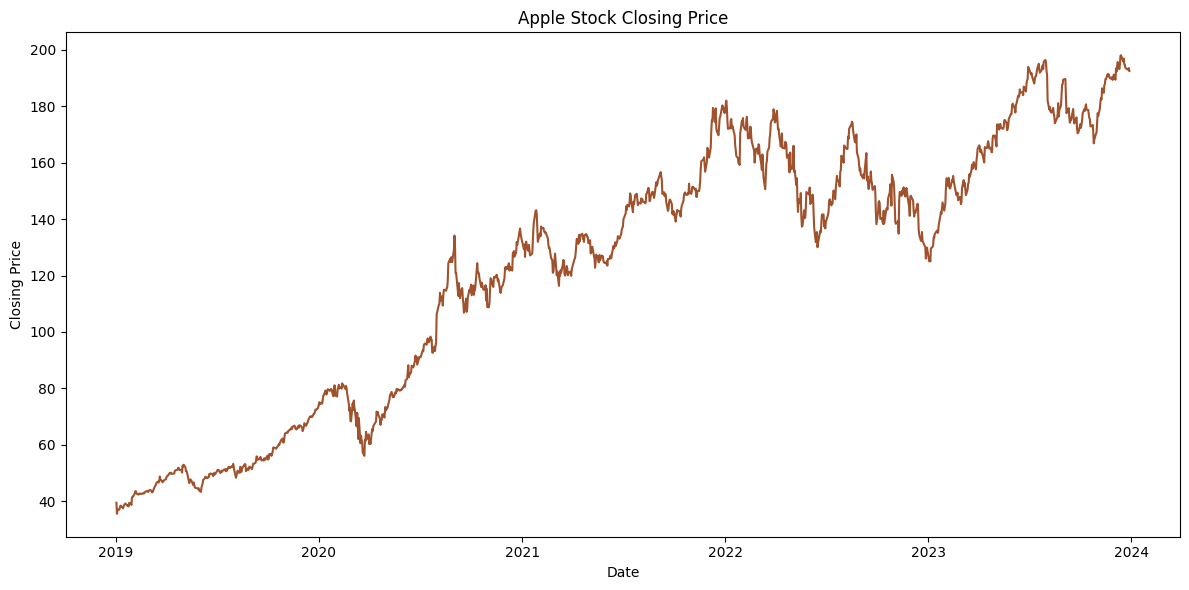

In [54]:
plt.figure(figsize=(12,6))

apple = df[df['Ticker'] == 'AAPL']

plt.plot(apple['Date'], apple['Close'], color = 'sienna')

plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.tight_layout()
plt.show()

## CONCLUSION
Apple stock showed a strong long-term upward trend from 2019–2024, indicating continuous company growth and investor confidence. Significant fluctuations can also be observed during major market events such as COVID-19 and post-pandemic recovery.

## **Volume Analysis**

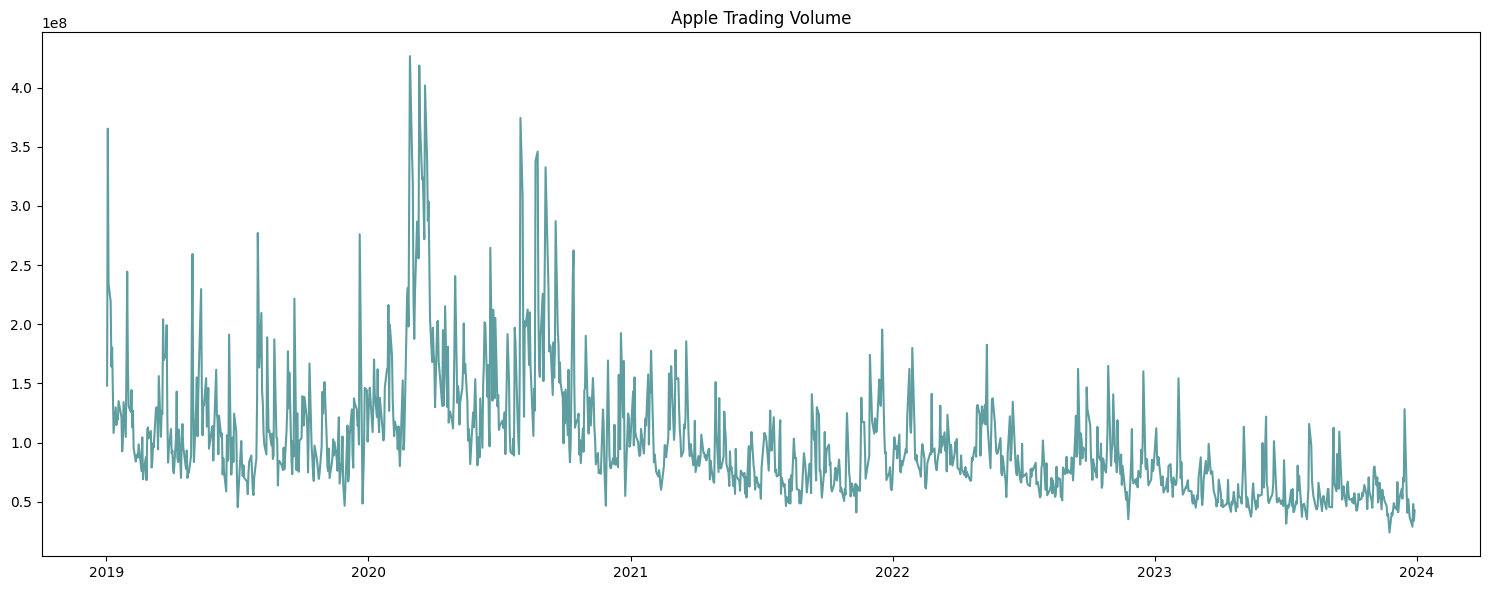

In [53]:
plt.figure(figsize=(15,6))

plt.plot(apple['Date'], apple['Volume'], color = 'cadetblue')

plt.title("Apple Trading Volume")
plt.tight_layout()
plt.show()

## CONCLUSION
The trading volume graph showed several sudden spikes during major market events. These spikes indicate periods of high investor activity and market uncertainty, especially during the COVID-19 crash and recovery phases.

## **Correlation Between Stocks**

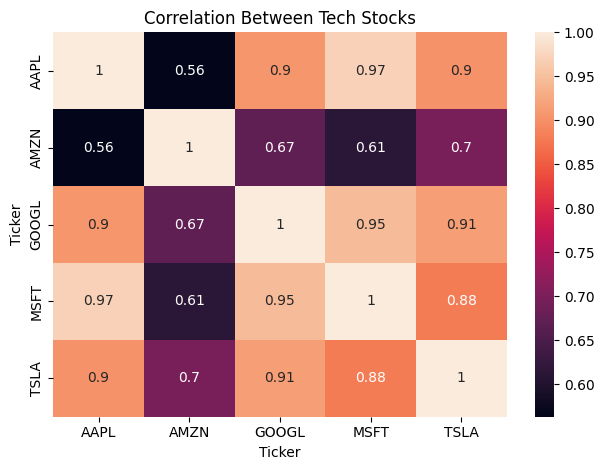

In [52]:
pivot_df = df.pivot(index='Date',
                    columns='Ticker',
                    values='Close')

sns.heatmap(pivot_df.corr(),
            annot=True)

plt.title("Correlation Between Tech Stocks")
plt.tight_layout()
plt.show()

## CONCLUSION
Most technology stocks demonstrated positive correlation with each other, indicating that companies within the tech sector tend to move in similar market directions due to shared economic and industry factors.

## **Daily Returns**

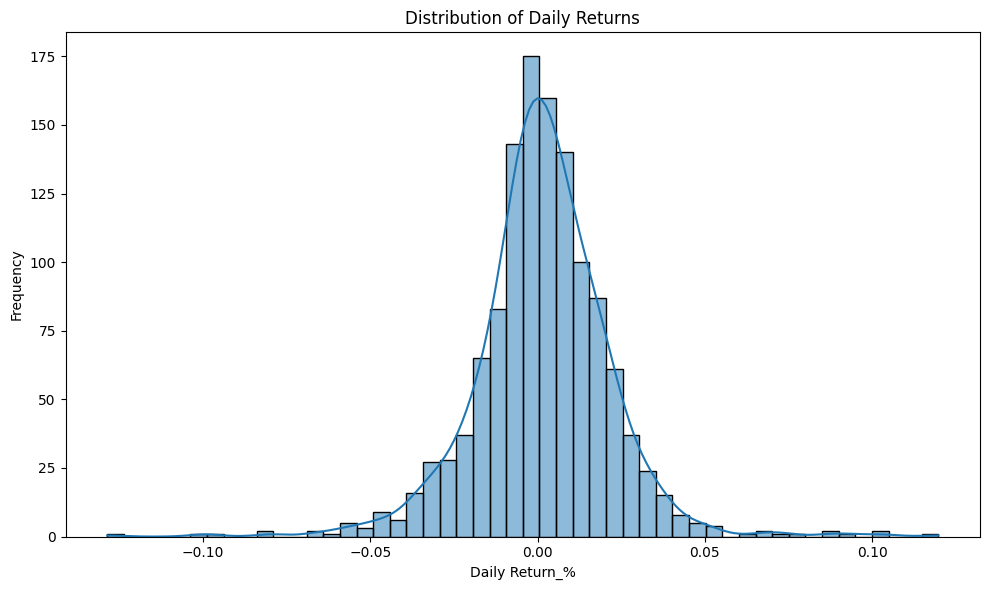

In [51]:
plt.figure(figsize=(10,6))

sns.histplot(apple['Daily_Return'],
             bins=50,
             kde=True)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return_%")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## CONCLUSION
Most daily returns are concentrated near zero, indicating that small daily price changes are more common. However, the presence of extreme values on both sides reflects occasional high volatility and sudden market movements.

## **Compare Tickers**

In [29]:
performance = []

for ticker in df['Ticker'].unique():

    temp = df[df['Ticker'] == ticker]

    initial_price = temp['Close'].iloc[0]
    final_price = temp['Close'].iloc[-1]

    returns = ((final_price - initial_price) / initial_price) * 100

    performance.append([ticker, returns])

performance_df = pd.DataFrame(performance,
                              columns=['Ticker', 'Return_%'])

performance_df = performance_df.sort_values(
                    by='Return_%',
                    ascending=False)

print(performance_df)

  Ticker     Return_%
4   TSLA  1101.857285
0   AAPL   387.664643
1   MSFT   271.874998
3  GOOGL   164.895512
2   AMZN    97.436224


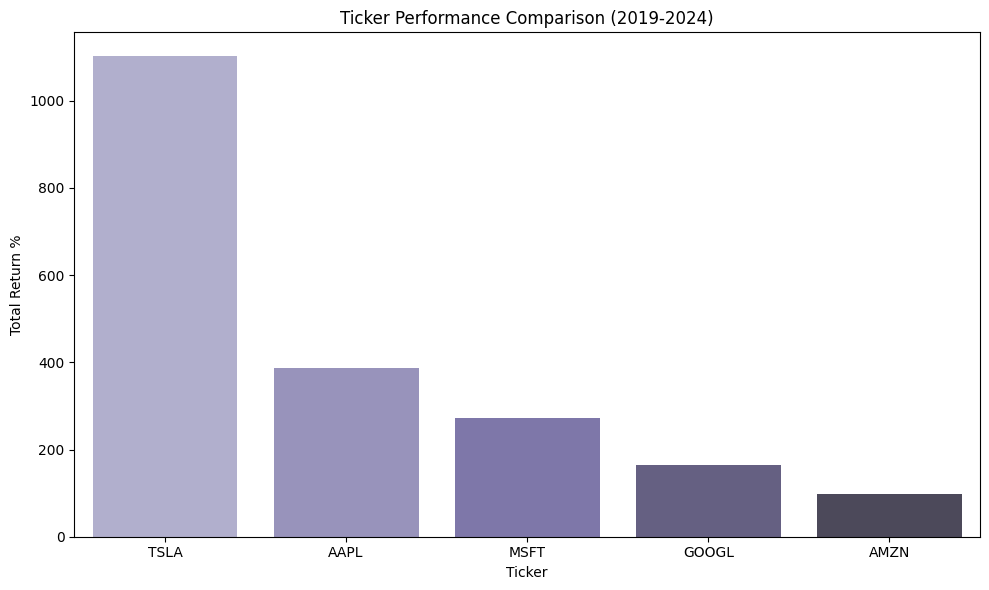

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(data=performance_df,
            x='Ticker',
            y='Return_%',
           palette='Purples_d',
           hue = 'Ticker')

plt.title("Ticker Performance Comparison (2019-2024)")
plt.ylabel("Total Return %")
plt.tight_layout()
plt.show()

## CONCLUSION
Tesla was the best-performing stock in the dataset with an overall return of approximately 1101.86%, significantly outperforming other major technology companies. Apple and Microsoft also demonstrated strong long-term growth with returns of 387.66% and 271.87% respectively.

## **Moving Average Analysis**

C:\Users\Sushil Kumar\AppData\Local\Temp\ipykernel_12688\286982993.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple['MA20'] = apple['Close'].rolling(20).mean()
C:\Users\Sushil Kumar\AppData\Local\Temp\ipykernel_12688\286982993.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple['MA50'] = apple['Close'].rolling(50).mean()


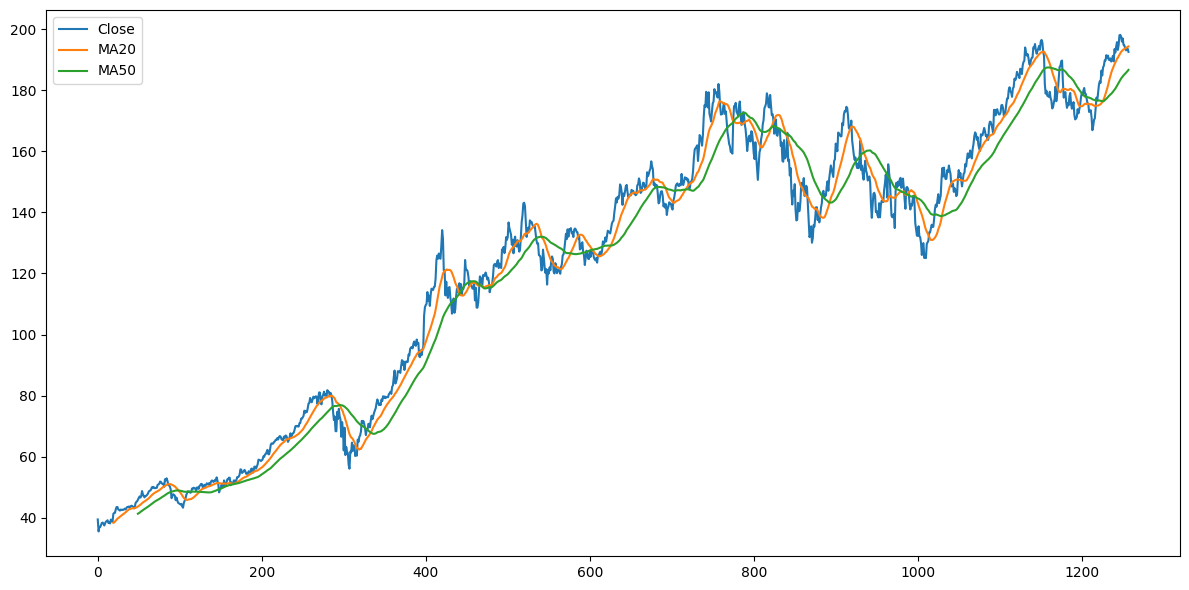

In [48]:
apple['MA20'] = apple['Close'].rolling(20).mean()
apple['MA50'] = apple['Close'].rolling(50).mean()

plt.figure(figsize=(12,6))

plt.plot(apple['Close'], label='Close')
plt.plot(apple['MA20'], label='MA20')
plt.plot(apple['MA50'], label='MA50')

plt.legend()
plt.tight_layout()
plt.show()

## CONCLUSION
The moving average analysis successfully captured trend reversals and momentum changes in stock prices. Crossovers between short-term and long-term moving averages highlighted potential buy and sell opportunities. Sustained periods where the short-term moving average remained above the long-term moving average indicated bullish market momentum.

## Final Conclusion
This project successfully analyzed historical stock market data of major technology companies from 2019–2024 using preprocessing and exploratory data analysis techniques. The analysis identified important market trends, volatility behavior, sector correlations, and significant differences in company performance. Among all companies, Tesla achieved the highest overall return of approximately 1101.86%, representing the strongest growth trend in the dataset. The study also identified abnormal market behavior during the COVID-19 crisis and demonstrated how trading volume and daily return distributions can be used to evaluate market risk and investor activity. Furthermore, a moving average crossover strategy was proposed and connected to historical backtesting methods for evaluating trading performance. Overall, the project demonstrates how financial data analytics can be applied to extract meaningful investment insights, identify market anomalies, and support data-driven decision making in financial markets.